In [26]:
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from torch import nn
import torch.optim
from torchinfo import summary


import config

from model_utils import train_test_split, FPLDataPipe, Trainer, set_seed, scale_data
from data_utils import sort_data, colors_config
from sklearn.preprocessing import MinMaxScaler



In [27]:
set_seed(77)
set_seed(77)

In [28]:
data = pd.read_parquet(config.FPL_DATA_PATH)

In [29]:
data = sort_data(data)
data.head()

,position_id,second_name_id,status_id,first_name_id,match_id,team_name_id,team_code_id,gw_id,season_id,web_name_id,player_code_id,team_strength,position,was_home,cost_change_event_lagged_1,transfers_in_event_lagged_1,accurate_crosses_lagged_1,accurate_long_balls_ema_8,transfers_out_event_ema_8,xg_lagged_1,xgot_lagged_1,assists_lagged_1,saves_ema_8,high_claim_ema_8,fouls_committed_ema_8,form_lagged_1,xg_ema_8,event_points,was_fouled_lagged_1,chances_created_lagged_1,gk_accurate_long_balls_lagged_1,successful_dribbles_ema_8,goals_ema_8,touches_opposition_box_ema_8,start_min_ema_8,gk_accurate_long_balls_ema_8,ground_duels_won_ema_8,interceptions_ema_8,shots_on_target_ema_8,recoveries_lagged_1,value_season_lagged_1,xa_ema_8,big_chances_missed_ema_8,sweeper_actions_ema_8,touches_lagged_1,offsides_ema_8,accurate_crosses_percent_ema_8,minutes_played_lagged_1,xg_per_90_ema_8,final_third_passes_ema_8,shots_on_target_lagged_1,event_points_lagged_1,bonus_ema_8,xgot_faced_lagged_1,value_ratio_ema_8,ep_this_ema_8,sweeper_actions_lagged_1,high_claim_lagged_1,tackles_ema_8,event_points_ema_8,team_goals_conceded_lagged_1,value_form_lagged_1,penalties_scored_ema_8,transfers_in_event_ema_8,accurate_crosses_ema_8,bps_lagged_1,accurate_passes_lagged_1,gk_accurate_passes_ema_8,headed_clearances_ema_8,goals_conceded_ema_8,xa_per_90_ema_8,ep_this_lagged_1,dribbled_past_lagged_1,aerial_duels_won_ema_8,dreamteam_count_lagged_1,duels_won_ema_8,goals_lagged_1,final_third_passes_lagged_1,dribbled_past_ema_8,expected_goal_involvements_per_90_ema_8,xgot_ema_8,team_goals_conceded_ema_8,was_fouled_ema_8,ep_next_lagged_1,duels_won_lagged_1,form_ema_8,cost_change_start_lagged_1,recoveries_ema_8,big_chances_missed_lagged_1,saves_lagged_1,now_cost_ema_8,ict_index_ema_8,minutes_played_ema_8,transfers_in_ema_8,goals_conceded_lagged_1,touches_ema_8,clearances_lagged_1,total_shots_ema_8,selected_rank_ema_8,value_form_ema_8,assists_ema_8,tackles_lagged_1,aerial_duels_won_lagged_1,penalties_missed_ema_8,duels_lost_ema_8,transfers_out_ema_8,transfers_out_event_lagged_1,now_cost_rank_lagged_1,clearances_ema_8,ground_duels_won_lagged_1,expected_assists_lagged_1,expected_goals_conceded_ema_8,start_min_lagged_1,touches_opposition_box_lagged_1,penalties_order_lagged_1,selected_by_percent_ema_8,headed_clearances_lagged_1,duels_lost_lagged_1,total_shots_lagged_1,accurate_passes_ema_8,xa_lagged_1,accurate_long_balls_lagged_1,successful_dribbles_lagged_1,chances_created_ema_8,fouls_committed_lagged_1,interceptions_lagged_1,threat_lagged_1,influence_lagged_1
0,Midfielder,Milner,a,James,24-25-prem-everton-vs-brighton-&-hove-albion,Brighton,36,1,2425,Milner,15157,3,MID,0,0,0,0,0.000000,0.000000,0.0,0.0,0,0.0,0.0,0.0,0.0,0.000000,2,0,0,0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0,0.0,0.000000,0.0,0.0,0,0.0,0.000000,0,0.000000,0.000000,0,0,0.0,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0,0.0,0.0,0.000000,0.000000,0,0,0.0,0.0,0.0,0.000000,0.0,0,0.0,0,0.000000,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0,0.000000,0,0.000000,0,0,0.0,0.000000,0.0,0.000000,0,0.000000,0,0.000000,0.000000,0.000000,0.0,0,0,0.0,0.000000,0.000000,0,0,0.000000,0,0.0,0.000000,0,0,0,0.0,0,0,0,0.000000,0.0,0,0,0.000000,0,0,0,0.0
1,Midfielder,Milner,a,James,24-25-prem-brighton-&-hove-albion-vs-mancheste...,Brighton,36,2,2425,Milner,15157,3,MID,1,0,513,2,1.000000,421.000000,0.0,0.0,0,0.0,0.0,1.0,2.0,0.000000,2,0,3,0,0.000000,0.0,2.000000,0.0,0.0,4.000000,0.000000,0.000000,0,0.4,0.110000,0.0,0.0,48,0.0,29.000000,82,0.000000,2.000000,0,2,0.0,0.0,0.400000,1.600000,0,0,4.000000,2.000000,0,0.4,0.0,513.000000,2.000000,10,28,0.0,0.0,0.0,0.120732,1.6,0,0.0,0,4.000000,0,2,0.0,0.120732,0.0,0.000000,0.000000,1.6,4,2.000000,0,0.000000,0,0,5.0,7.000000,82.0,513.000000,0,48.000000,0,0.000000,471.000000,0.400000,0.0,4,0,0.0,2.000000,421.000000,421,172,0.000000,4,0.11,0.450000,0,2,6,0.1,0,2,0,28.000000,0.11,1,0,3.000000,1,0,4,22.4
2,Midfielder,Milner,d,James,24-25-prem-arsenal-vs-brighton-&-hove-albion,Brighton,36

In [30]:
data.shape

(20820, 128)

In [31]:
cols_map = colors_config.FEATURES_GROUP

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [33]:
cols_map.keys()

dict_keys(['target', 'cols_id', 'static_cols', 'order_cols', 'ratio_features', 'performance_cols', 'pre_game_cols'])

In [34]:
cols_map["static_cols"]

['status', 'position', 'was_home', 'team_strength']

In [35]:
cols_map["pre_game_cols"]

['selected_by_percent',
 'cost_change_event',
 'transfers_out',
 'transfers_in_event',
 'transfers_out_event',
 'ep_this',
 'ep_next']

In [36]:
num_cols = [c for c in data.columns if "ema" in c or "lagg" in c]
len(num_cols)

113

In [37]:
static_cols = [f"{c}_id" for c in cols_map["static_cols"] if c not in  ["was_home", "team_strength"]] + ["was_home", "team_strength"]

In [38]:
static_cols

['status_id', 'position_id', 'was_home', 'team_strength']

In [39]:
BATCH_SIZE = 64
fpl_data_pipe = FPLDataPipe(num_cols=num_cols,
                            cat_cols = static_cols,
                            batch_size=BATCH_SIZE)

In [40]:
scaler = MinMaxScaler()

In [41]:
data_splits = train_test_split(data)

data_splits["y_train"] = pd.Series(
    scaler.fit_transform(data_splits["y_train"].to_frame()).flatten(),
    index=data_splits["y_train"].index
)

data_splits["y_valid"] = pd.Series(
    scaler.transform(data_splits["y_valid"].to_frame()).flatten(),
    index=data_splits["y_valid"].index
)

data_splits["y_test"] = pd.Series(
    scaler.transform(data_splits["y_test"].to_frame()).flatten(),
    index=data_splits["y_test"].index
)

In [42]:

fpl_data_pipe.prepare_data(**data_splits)

In [43]:
train_dataloader, valid_dataloader, test_dataloader = fpl_data_pipe.get_dataloaders()

In [44]:
x, y = next(iter(train_dataloader))
x.shape, y.shape

(torch.Size([64, 129]), torch.Size([64, 1]))

In [45]:
class MLP(nn.Module):
    def __init__(self, input_size: int,
                 hidden_size1: int,
                 hidden_size2: int,
                 output_size: int):
        super(MLP, self).__init__()

        block1 = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(0.3)
        )
        block2 = nn.Sequential(
            nn.Linear(hidden_size1, hidden_size2),
            nn.LeakyReLU(.01),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(0.2)
        )
        block3 = nn.Sequential(
            nn.Linear(hidden_size2, output_size)
        )

        self.block_stack = nn.Sequential(
            block1,
            block2,
            block3
        )

    def forward(self, x):
        return self.block_stack(x)

In [46]:
data.shape

(20820, 128)

In [47]:
mlp = MLP(
    input_size=x.shape[1],
    hidden_size1=128,
    hidden_size2=64,
    output_size=1
).to(device)

In [48]:
summary(
    model=mlp,
    input_size=(BATCH_SIZE, x.shape[1]),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18

)

Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
MLP                                      [64, 129]          [64, 1]            --                 True
├─Sequential: 1-1                        [64, 129]          [64, 1]            --                 True
│    └─Sequential: 2-1                   [64, 129]          [64, 128]          --                 True
│    │    └─Linear: 3-1                  [64, 129]          [64, 128]          16,640             True
│    │    └─LeakyReLU: 3-2               [64, 128]          [64, 128]          --                 --
│    │    └─BatchNorm1d: 3-3             [64, 128]          [64, 128]          256                True
│    │    └─Dropout: 3-4                 [64, 128]          [64, 128]          --                 --
│    └─Sequential: 2-2                   [64, 128]          [64, 64]           --                 True
│    │    └─Linear: 3-5                  [64, 128]          [64, 64]    

In [49]:
learning_rate = 0.001
weight_decay = .01
loss_fn = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(lr=learning_rate,
                            params=mlp.parameters(),
                            weight_decay=weight_decay)


In [50]:
trainer = Trainer(device=device,
                  random_state=77)

In [51]:
NUM_EPOCHS = 400
results, best_model = trainer.model_eval(train_dataloader=train_dataloader,
                             test_dataloader=valid_dataloader,
                             model=mlp,
                             num_epochs=NUM_EPOCHS,
                             optimizer=optimizer,
                             loss_fn=loss_fn,
                             tolerance=0.0000001,
                             patience=NUM_EPOCHS//10)

  0%|          | 0/400 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 0.0387 | Test Loss: 0.0049
Train MSE: 0.0795 | Test MSE: 0.0098
Train MAE: 0.1982 | Test MAE : 0.0685
Train R2: -9.4835 | Test R2: -0.2558
Epoch: 40 | Train Loss: 0.0034 | Test Loss: 0.0040
Train MSE: 0.0067 | Test MSE: 0.0080
Train MAE: 0.0581 | Test MAE : 0.0591
Train R2: 0.1164 | Test R2: -0.0162
Early stopping | No improvement since 40 epochs


In [52]:
results_frame = pd.DataFrame(results)
results_frame.tail()

,train_loss,test_loss,train_mse,test_mse,train_mae,test_mae,train_r2,test_r2
47,0.003324,0.003859,0.006648,0.007733,0.057678,0.059701,0.123580,0.013370
48,0.003309,0.003859,0.006621,0.007733,0.057404,0.059085,0.127046,0.013415
49,0.003317,0.003952,0.006635,0.007919,0.057409,0.059714,0.125296,-0.010323
50,0.003288,0.003800,0.006576,0.007614,0.056967,0.061148,0.133034,0.028553
51,0.003306,0.003819,0.006611,0.007652,0.057431,0.060687,0.128409,0.023740


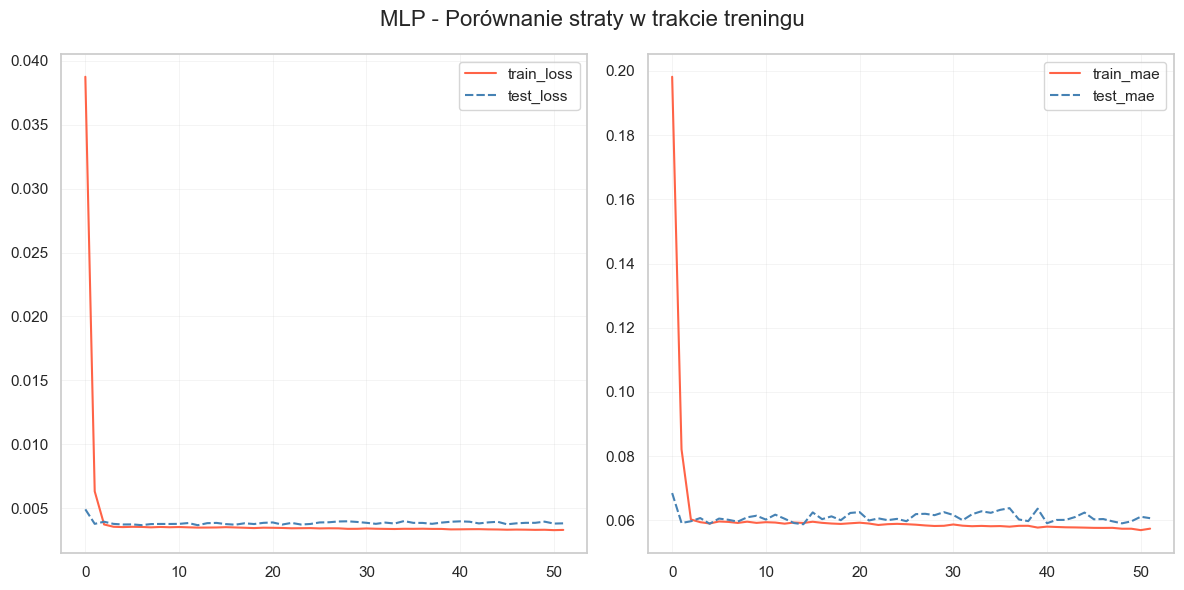

In [53]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.lineplot(results_frame[["train_loss", "test_loss"]],
             palette=["tomato", "steelblue"],
             ax=ax[0])
sns.lineplot(results_frame[["train_mae", "test_mae"]],
             palette=["tomato", "steelblue"],
             ax=ax[1])
fig.suptitle("MLP - Porównanie straty w trakcie treningu", fontsize=16)
plt.tight_layout()


In [54]:
mlp.load_state_dict(best_model)
mlp.eval()

MLP(
  (block_stack): Sequential(
    (0): Sequential(
      (0): Linear(in_features=129, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.2, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

In [55]:
test_results = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[0:3]

y_pred = trainer.test_step(test_dataloader=test_dataloader, model=mlp, loss_fn=loss_fn)[4]

In [56]:
y_test = data_splits["y_test"]

In [57]:
y_pred.shape, y_test.shape

(torch.Size([4788, 1]), (4788,))

In [58]:
preds = pd.DataFrame({
    "name" : data.loc[y_test.index, "web_name_id"],
    "y_true": y_test.values,
    "y_pred": y_pred.numpy().flatten()
})

In [59]:
preds.y_pred.max(), preds.y_true.max()

(np.float32(0.37652987), np.float64(0.7647058823529412))

In [60]:
preds.head()

,name,y_true,y_pred
11,Milner,0.176471,0.202569
12,Milner,0.176471,0.214789
13,Milner,0.176471,0.216757
14,Milner,0.176471,0.216886
15,Milner,0.176471,0.216091


In [61]:
players = data.loc[y_test.index, ["web_name_id", "team_name_id"]].sample(8, random_state=2122)
players

,web_name_id,team_name_id
20462,Dorgu,Man Utd
18766,Schade,Brentford
13135,Reinildo,Sunderland
18230,Ugochukwu,Burnley
16264,Estève,Burnley
19187,Hinshelwood,Brighton
6300,Cash,Aston Villa
15224,Saliba,Arsenal


In [62]:
players = players.web_name_id

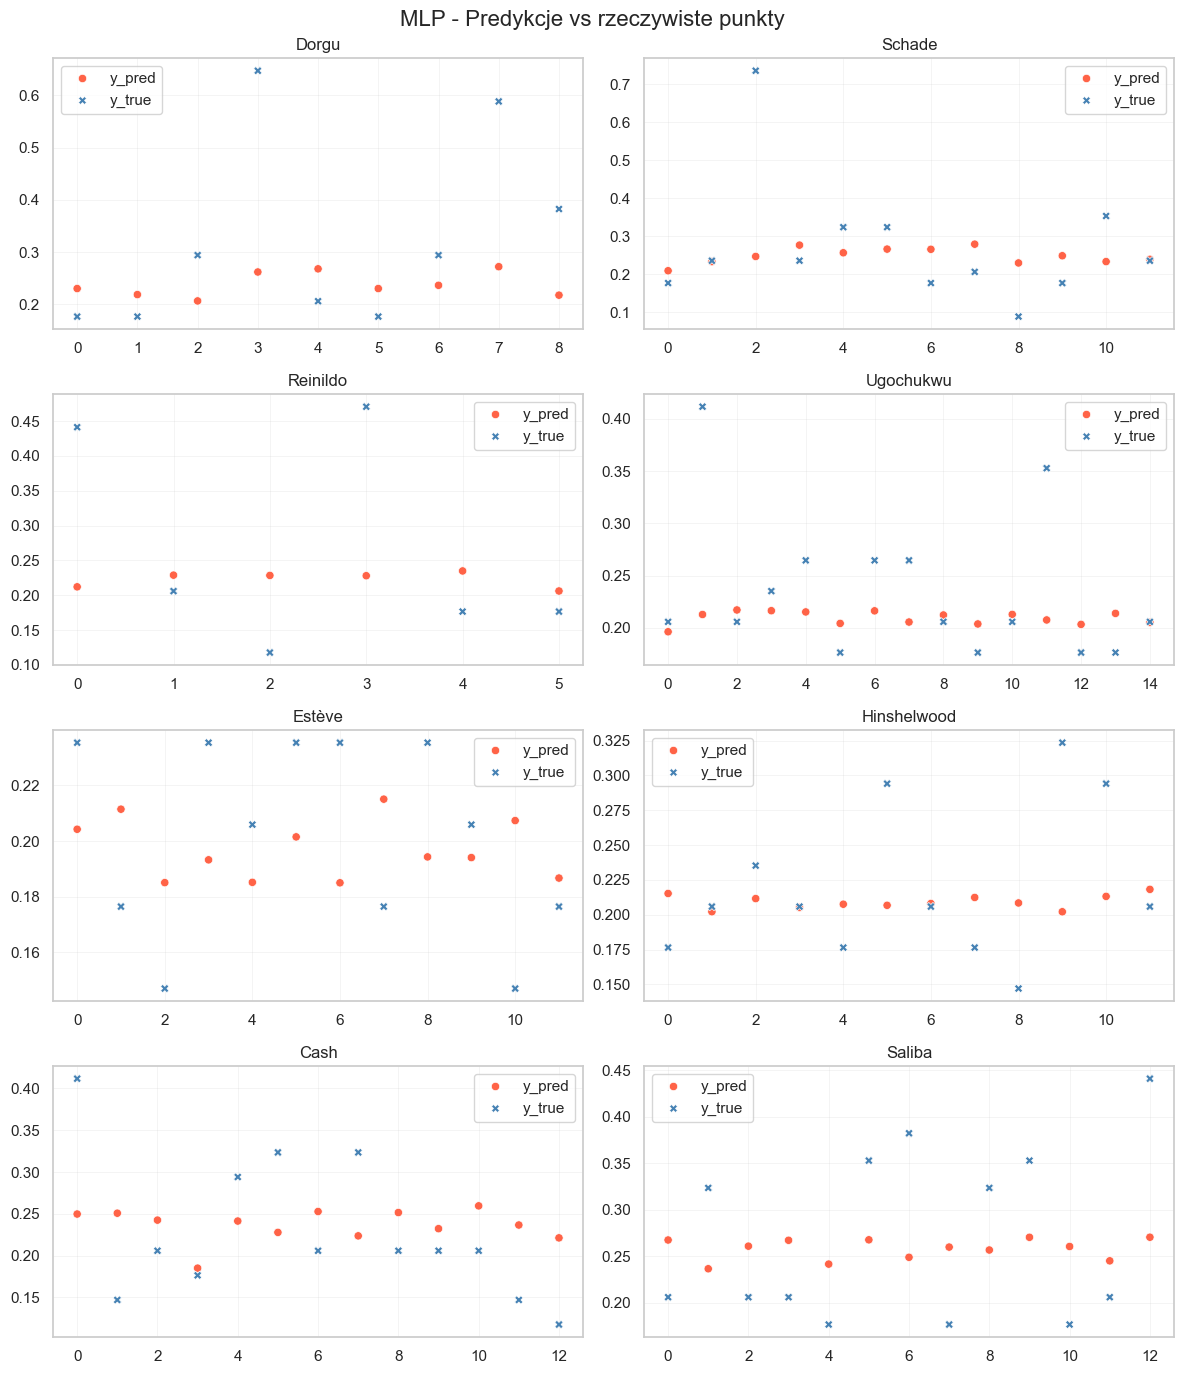

In [63]:
fig, ax = plt.subplots(nrows=4, ncols=len(players) // 4, figsize=(12, 14))
for i, player in enumerate(players):
    sns.scatterplot(data=preds.loc[preds.name==player, ["y_pred", "y_true"]].reset_index(drop=True),
                    palette=["tomato", "steelblue"], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(player)
plt.suptitle("MLP - Predykcje vs rzeczywiste punkty", fontsize=16)
plt.tight_layout();


<Axes: >

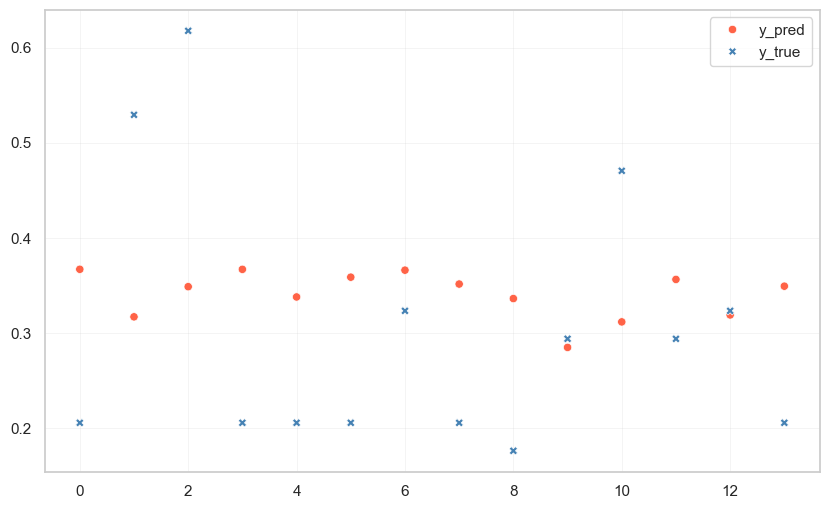

In [64]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=preds.loc[preds.name=="Haaland", ["y_pred", "y_true"]].reset_index(drop=True),
                    palette=["tomato", "steelblue"])

